### Step 1
Import required libraries and load the processed dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("../dataset/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


### Step 2
Separate features and target variable, then create train-test splits.

In [ ]:
x=df.drop(['quality'],axis=1)
y=df['quality']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,
y,
test_size=0.2,
random_state=42)

### Step 3
Scale features using StandardScaler for algorithms sensitive to feature magnitude.

In [3]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

### Step 4
Train and evaluate a Random Forest Classifier.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier(n_estimators=200,
random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6943231441048034


### Step 5
Train and evaluate a Stochastic Gradient Descent Classifier.

In [11]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(
    random_state=42
)
sgd.fit(x_train_scaled, y_train)
sgd_pred = sgd.predict(x_test_scaled)
sgd_acc = accuracy_score(y_test, sgd_pred)
print("SGD Accuracy:", sgd_acc)

SGD Accuracy: 0.5851528384279476


### Step 6
Train and evaluate a Support Vector Classifier.

In [12]:
from sklearn.svm import SVC
svc = SVC(
    kernel='rbf',
    random_state=42
)
svc.fit(x_train_scaled, y_train)

svc_pred = svc.predict(x_test_scaled)
svc_acc = accuracy_score(y_test, svc_pred)
print("SVC Accuracy:", svc_acc)

SVC Accuracy: 0.6550218340611353


### Step 7
Generate a classification report for detailed model evaluation.

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.76      0.74        96
           6       0.66      0.70      0.68        99
           7       0.74      0.65      0.69        26
           8       0.00      0.00      0.00         2

    accuracy                           0.69       229
   macro avg       0.42      0.42      0.42       229
weighted avg       0.67      0.69      0.68       229



C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

### Step 8
Visualize prediction performance using a confusion matrix.

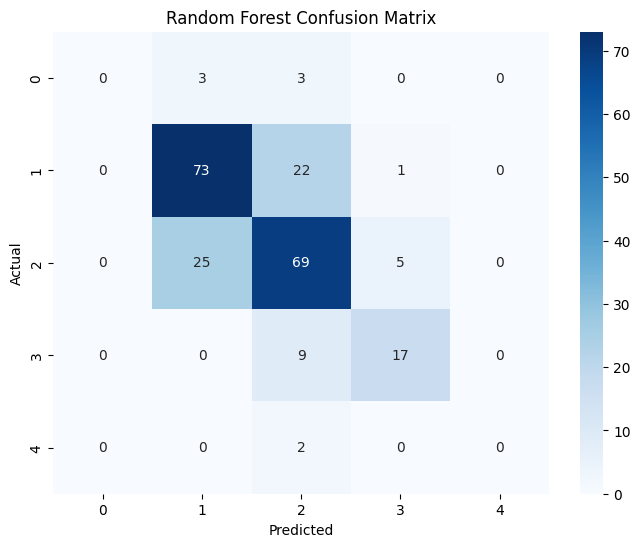

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Step 9
Analyze Random Forest feature importance scores.

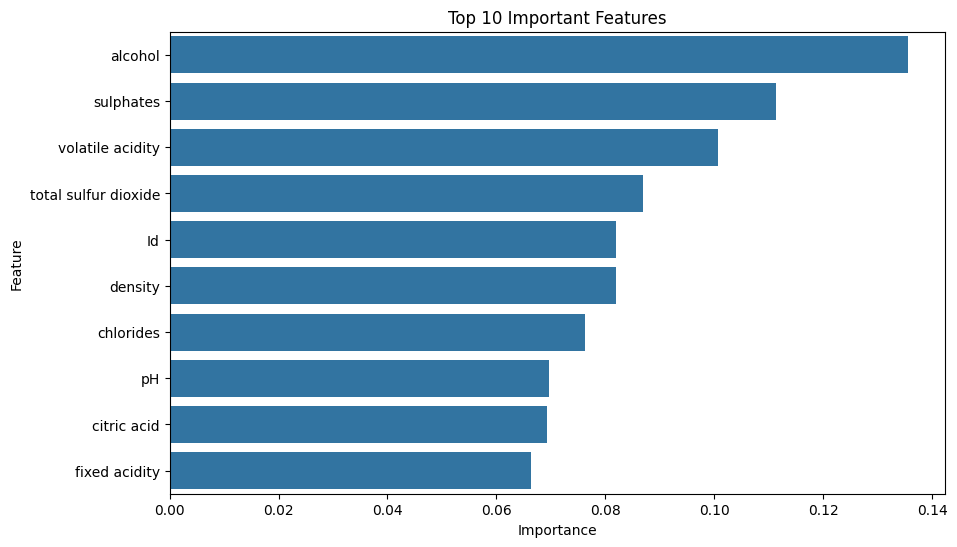

In [20]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

### Step 10
Compare the performance of all trained models.

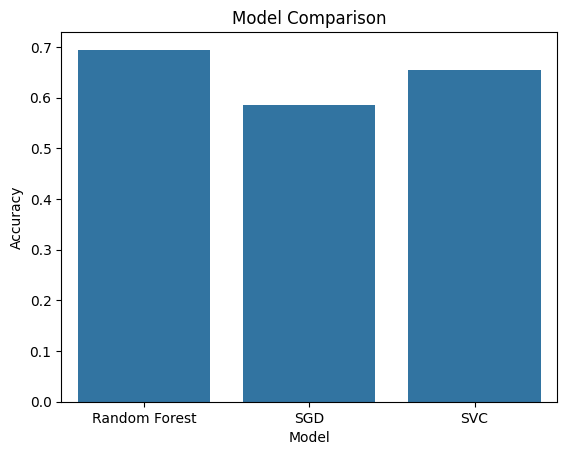

In [19]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [rf_acc, sgd_acc, svc_acc]
})

results
sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Comparison")
plt.show()